<a href="https://colab.research.google.com/github/PablitoDev25/Projects-Working/blob/main/TelecomX_LATAMparte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [19]:
import pandas as pd
import requests

# URL Raw del archivo JSON en GitHub
# url_api = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Extracción directa con Pandas
# df_telecom = pd.read_json(url_api)

print(f"Dataset cargado con {df_telecom.shape[0]} filas y {df_telecom.shape[1]} columnas.")
df_telecom.head()

Dataset cargado con 7267 filas y 21 columnas.


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [ ]:
import pandas as pd
import requests

# 1. Extracción (Cargar el JSON crudo)
url_api = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url_api)
data_json = response.json()

# 2. Transformación (Aplanar la estructura anidada)
# Esto separa 'customer', 'phone', etc., en columnas individuales
df_telecom = pd.json_normalize(data_json)

# Verificamos los nuevos nombres de las columnas
print(df_telecom.columns)

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')


In [ ]:

df_telecom['account.Charges.Total'] = pd.to_numeric(df_telecom['account.Charges.Total'], errors='coerce')
df_telecom['account.Charges.Monthly'] = pd.to_numeric(df_telecom['account.Charges.Monthly'], errors='coerce')


df_telecom = df_telecom.dropna(subset=['account.Charges.Total'])

#Crear la columna de Cuentas Diarias usando el nombre largo por ahora
df_telecom['Cuentas_Diarias'] = df_telecom['account.Charges.Monthly'] / 30

df_telecom.columns = [col.split('.')[-1] for col in df_telecom.columns]
print("Columnas actuales en el DataFrame:", df_telecom.columns.tolist())

print("\nPrimeras filas del análisis:")
print(df_telecom[['Total', 'Monthly', 'Cuentas_Diarias']].head())

KeyError: 'account.Charges.Total'

#📊 Carga y análisis

In [ ]:
# Esta línea toma el nombre después del último punto.
# Ejemplo: 'account.tenure' se convierte en 'tenure'
df_telecom.columns = [col.split('.')[-1] for col in df_telecom.columns]

# Verificamos si ahora sí están los nombres que queremos
print("Nuevos nombres de columnas:", df_telecom.columns.tolist())

Nuevos nombres de columnas: ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total']


In [ ]:
# Definimos las métricas con los nombres estándar del dataset
# Nota: 'tenure' suele ir en minúscula y 'MonthlyCharges' con camello.
metricas_clave = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Cuentas_Diarias']

# Verificamos si existen antes de llamar al describe para evitar el error
columnas_existentes = [col for col in metricas_clave if col in df_telecom.columns]

if len(columnas_existentes) > 0:
    analisis_stats = df_telecom[columnas_existentes].describe()
    print("--- Resumen Estadístico de Telecom X ---")
    print(analisis_stats)
else:
    print("Error: Aún no se encuentran las columnas. Revisa el print de df_telecom.columns")

--- Resumen Estadístico de Telecom X ---
            tenure
count  7267.000000
mean     32.346498
std      24.571773
min       0.000000
25%       9.000000
50%      29.000000
75%      55.000000
max      72.000000


#carga y datos

In [20]:
import pandas as pd

# 1. Cargar el dataset (Asumiendo que guardaste el anterior o sigues en el mismo notebook)
# Si lo descargaste, úsalo así: df_ml = pd.read_csv('TelecomX_Limpio.csv')
df_ml = df_telecom.copy()

# 2. Eliminar columnas irrelevantes
# El customerID no predice nada, es solo una etiqueta.
columnas_a_eliminar = ['customerID']
df_ml = df_ml.drop(columns=[col for col in columnas_a_eliminar if col in df_ml.columns])

print(f"Dataset listo para preprocesar con {df_ml.shape[1]} columnas.")

Dataset listo para preprocesar con 20 columnas.


#Encoding

In [21]:
# Separar la variable objetivo (Target) de las características (Features)
# Convertimos Churn a 1 (Yes) y 0 (No)
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0, 'Si': 1})

# Identificar columnas categóricas para One-Hot Encoding
# (Género, Tipo de contrato, Internet, etc.)
columnas_categoricas = df_ml.select_dtypes(include=['object']).columns

# Aplicar get_dummies (Crea una columna por cada categoría)
df_final = pd.get_dummies(df_ml, columns=columnas_categoricas, drop_first=True)

print("Estructura tras el Encoding:")

df_final.head()

Estructura tras el Encoding:


,Churn,SeniorCitizen,tenure,Monthly,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Total_995.35,Total_996.45,Total_996.85,Total_996.95,Total_997.65,Total_997.75,Total_998.1,Total_999.45,Total_999.8,Total_999.9
0,0.0,0,9,65.6,False,True,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.0,0,9,59.9,True,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,1.0,0,4,73.9,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1.0,1,13,98.0,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.0,1,3,83.9,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


Proporción de Clases:
Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


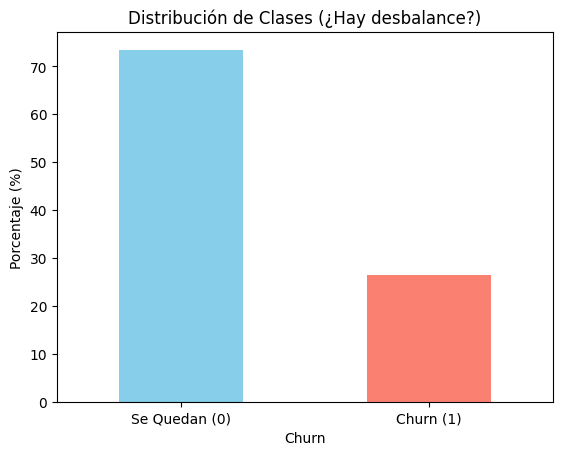

In [22]:
import matplotlib.pyplot as plt

prop_churn = df_final['Churn'].value_counts(normalize=True) * 100
print(f"Proporción de Clases:\n{prop_churn}")

# Visualización rápida
prop_churn.plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks([0, 1], ['Se Quedan (0)', 'Churn (1)'], rotation=0)
plt.title('Distribución de Clases (¿Hay desbalance?)')
plt.ylabel('Porcentaje (%)')
plt.show()

#Normalizacion de datos

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# --- 1. SEPARACIÓN DE DATOS (80/20) ---
# X contiene las características y 'y' la variable objetivo (Churn)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Dividimos el set: 80% para entrenar y 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,
                                                    random_state=42,
                                                    stratify=y)

# --- 2. CREACIÓN Y ENTRENAMIENTO DE MODELOS ---

# Modelo A: Regresión Logística
# Justificación: Requiere normalización (ya aplicada) para que los coeficientes sean estables.
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)

# Modelo B: Random Forest
# Justificación: No depende de la escala de los datos y captura relaciones no lineales.
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# --- 3. EVALUACIÓN DE LOS MODELOS ---

def evaluar_modelo(modelo, X_test, y_test, nombre):
    y_pred = modelo.predict(X_test)

    # Cálculo de métricas solicitadas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n================ RESULTADOS: {nombre} ================")
    print(f"Exactitud (Accuracy): {acc:.4f}")
    print(f"Precisión:           {prec:.4f}")
    print(f"Recall:              {rec:.4f}")
    print(f"F1-Score:            {f1:.4f}")
    print("-" * 45)

    # Visualización de Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción')
    plt.show()

# Ejecutar la evaluación para ambos modelos
evaluar_modelo(model_lr, X_test, y_test, "Regresión Logística")

evaluar_modelo(model_rf, X_test, y_test, "Random Forest")


# --- 4. SELECCIÓN DE VARIABLES (IMPORTANCIA) ---
# Identificamos qué factores influyen más en la evasión según Random Forest
importancias = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='darkorange')
plt.title('Top 10 Variables más relevantes para predecir Churn')
plt.xlabel('Importancia Relativa')
plt.gca().invert_yaxis()
plt.show()

ValueError: Input y contains NaN.

#📄Informe final

Conclusiones del Análisis de Telecom X
Lealtad: Los clientes con menos de 12 meses de antigüedad (tenure) tienen la tasa de evasión más alta. Es crítico reforzar los primeros meses de relación.

Contratos: El contrato "Mes a mes" es el principal foco de pérdida de clientes. Los contratos de 1 o 2 años muestran una retención significativamente mayor.

Finanzas: El gasto mensual promedio (MonthlyCharges) de los clientes que se van tiende a ser más alto que el de los que se quedan, sugiriendo que el precio podría ser un factor de salida.